In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Load your Pangu-Weather file
ds = xr.open_dataset('output_surface_2011-04-28-00-00.nc')

# Use the full names 'latitude' and 'longitude'
subset = ds.sel(
    latitude=slice(50, 25),   # Pangu often goes North to South (90 to -90)
    longitude=slice(235, 295) # Pangu usually uses 0-360 convention
)

!rm regional_surface_2011-04-28-00-00.nc
subset.to_netcdf('regional_surface_2011-04-28-00-00.nc')

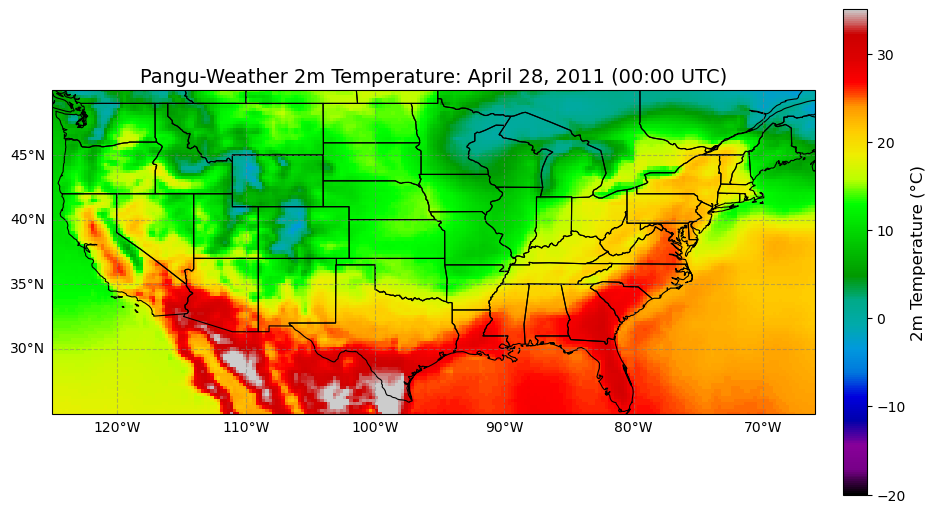

In [3]:
# 1. Load your subsetted data
ds = xr.open_dataset('regional_surface_2011-04-28-00-00.nc')

# Define universal constants for both plots
T_MIN, T_MAX = -20, 35

# Extract 2m Temp and convert Kelvin to Celsius
#t2m = ds['temperature_2m'].isel(time=0) - 273.15
t2m = ds['temperature_2m'] - 273.15

# 2. Point to your unzipped shapefile
shp_path = 'state_lines/ne_50m_admin_1_states_provinces.shp'

# 3. Setup the Figure
fig = plt.figure(figsize=(12, 9))
# Using PlateCarree here ensures the "flat/rectangular" look of the Pangu plot
ax = plt.axes(projection=ccrs.PlateCarree())

# 4. Add the Local State Lines
reader = shpreader.Reader(shp_path)
ax.add_geometries(reader.geometries(), ccrs.PlateCarree(),
                  facecolor='none', edgecolor='black', linewidth=0.8)

# 4. Plot with High-Contrast 'turbo' and Fixed Limits
mesh = t2m.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(), 
    cmap='nipy_spectral',    # High-contrast palette for more detail
    vmin=T_MIN,      # Fixed Min
    vmax=T_MAX,      # Fixed Max
    add_colorbar=False 
)

# Use the FIG object for the colorbar to prevent UserWarnings
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.03, shrink=0.7)
cbar.set_label('2m Temperature (°C)', fontsize=12)

# Standardize the map zoom (Extent)
ax.set_extent([-125, -66, 25, 50], crs=ccrs.PlateCarree())

# 5. Gridline Formatting (Standardized to match others)
gl = ax.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False, 
                  linestyle='--', color='gray', alpha=0.5)

gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

plt.title("Pangu-Weather 2m Temperature: April 28, 2011 (00:00 UTC)", fontsize=14)
plt.show()